In [74]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,BatchNormalization
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import pickle as pkl
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,confusion_matrix




In [2]:
type(tf.keras.datasets)

module

In [3]:
dir(tf.keras.datasets)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'boston_housing',
 'california_housing',
 'cifar10',
 'cifar100',
 'fashion_mnist',
 'imdb',
 'mnist',
 'reuters']

In [4]:
dir(tf.keras.datasets.fashion_mnist)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'load_data']

In [5]:
type(tf.keras.datasets.fashion_mnist)

module

In [6]:
type(tf.keras.datasets.fashion_mnist.load_data)

function

In [7]:
data=tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
type(data)

tuple

In [9]:
dir(data)

['__add__',
 '__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getnewargs__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__mul__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmul__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'count',
 'index']

In [10]:
len(data)

2

In [11]:
type(data[0])

tuple

In [12]:
len(data[0])

2

## Structure of `data`

```text
data (tuple)
│
├── data[0] → Training Data (tuple)
│   │
│   ├── data[0][0] → X_train (NumPy array)
│   │                Shape: (60000, 28, 28)
│   │
│   └── data[0][1] → y_train (NumPy array)
│                    Shape: (60000,)
│
└── data[1] → Testing Data (tuple)
    │
    ├── data[1][0] → X_test (NumPy array)
    │                Shape: (10000, 28, 28)
    │
    └── data[1][1] → y_test (NumPy array)
                     Shape: (10000,)
```

In [13]:
type(data[0][0])

numpy.ndarray

In [14]:
type(data[0][1])

numpy.ndarray

In [15]:
data[0][0].shape

(60000, 28, 28)

In [16]:
data[0][1].shape

(60000,)

In [17]:
train_images,train_labels=data[0]
test_images,test_lables=data[1]

In [18]:
train_images[59999]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   1,  71,  13,   4,   0,   0,   1,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,  62,  13,   0,  34,   0,   0,   0,   0,   0,   4,  42,  19,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0, 104,  68,   0,  51,  37,  28,  19,  47,  72,  95, 109,  59,
          0,   0],
       [  0,   0,   1,   0,   0,   1,   1,   0,   0,   1,   1,   0,   0,
          0,   0, 148, 133,  28,  42,  33,  27,  94,  98,  54,  97,  57,
          0,   3],
       [  1,   0,   1,   0,   4,   0,   0,   0,   0,   0,   0,   1,   0,
          6,   0,  27, 119, 101,   4,  75,  37,  27,  81, 130,  94,   0,
          0,   1],
       [  3,   1,   0,   0,   0,   0, 133, 157,   7,  21,   1,   0,   0,
          0,   0,   0,   0, 106, 145,  86,   4,  80, 124,  25,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   9,  56, 144, 133, 129, 153,  34,   0,   3,
          3,   0,   3,   0,  24, 104,  89, 104, 109,   0,   0,   0,   1,
          1,   0],
       [  1,   1,   3,   0,  25, 157, 170, 157, 201, 204,  25,   0,   0,
          0,   0,   0,   0,  51,  86,  94,  92,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  37,  91,   0,   0,  86,   0,   0,   0,
         36,  92, 129, 148,  66, 100,  68,  98, 173, 133, 122, 136, 127,
        112,  21],
       [ 22,  27,  19,  37,  44,  83,  59,  56,  45,  51, 163, 177, 173,
        200, 176, 177, 188,  66, 122,  89,  92, 183, 174, 185, 180, 177,
        177,  47],
       [101, 235, 194, 223, 232, 255,  98,  75,  54, 136,  85, 218, 186,
        186, 168, 195, 177,  37,  48,  22,  77, 221, 191, 183, 180, 160,
        186,  57],
       [  4,  86,  62,  54,  34,  28,  95,  86,  81,  98,  78,  77,  83,
         75,  88,  88,  89,  63,  75,  81,  86,  88,  66,  51,  42,  21,
         18,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [19]:
train_labels[59999]

np.uint8(5)

In [20]:
number, count =np.unique(train_labels,return_counts=True)

In [21]:
print(number)
print(count)

[0 1 2 3 4 5 6 7 8 9]
[6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


In [22]:
lable_count=zip(number,count)

In [23]:
for number, count in lable_count:
  print(f"number {number}: count {count}")

number 0: count 6000
number 1: count 6000
number 2: count 6000
number 3: count 6000
number 4: count 6000
number 5: count 6000
number 6: count 6000
number 7: count 6000
number 8: count 6000
number 9: count 6000


"I'm preparing the image for the neural network."

Preparation means:

Convert integers → floating-point numbers (float32). Normalize values from 0–255 to 0–1.
This process is called Normalization (or more specifically, Pixel Value Normalization).

Why?

Original pixel values: 0–255
After normalization: 0.0–1.0

So you're scaling the input features to a smaller range.

In [24]:
train_images=train_images/255.0
test_images=test_images/255.0

In [25]:
train_images[59999]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [26]:
len(train_images)

60000

In [27]:
train_images[0].shape

(28, 28)

In [28]:
train_images.shape

(60000, 28, 28)

In [29]:
train_labels[0]

np.uint8(9)

### One-Hot Encoding

The training and testing labels are converted from integer class labels (0–9) into one-hot encoded vectors using TensorFlow's `tf.keras.utils.to_categorical()` function. This format is required because the output layer contains 10 neurons and the model is trained using the `categorical_crossentropy` loss function.

In [30]:
train_labels =tf.keras.utils.to_categorical(train_labels)
test_labels =tf.keras.utils.to_categorical(test_lables)

"I performed two preprocessing steps. First, I normalized the image pixel values by dividing them by 255.0 so that all input features lie between 0 and 1, which helps the neural network train more efficiently. Second, I converted the integer class labels into one-hot encoded vectors using tf.keras.utils.to_categorical() because the model uses a Softmax output layer with the categorical_crossentropy loss function."

Why do we normalize images but not labels?

A strong answer is:

"We normalize images because pixel values are numerical input features, and scaling them to the range 0–1 helps the neural network train more efficiently. Labels, however, are categorical identifiers, not numerical measurements. Their magnitude has no mathematical meaning, so instead of normalizing them, we convert them into one-hot encoded vectors to match the probability distribution produced by the Softmax output layer.

In [31]:
train_labels[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

## Why Do We Use `Flatten()`?

The Fashion MNIST dataset contains **60,000 grayscale images**, where each image has a shape of **28 × 28** pixels.

Before passing the images to a **Fully Connected Neural Network (FCNN)**, each image must be converted into a **one-dimensional feature vector**, because a Dense layer expects each sample to be represented as a 1D vector.

### Original Dataset Shape

```python
train_images.shape
```

**Output**

```text
(60000, 28, 28)
```

This means:

- **60,000** training images
- Each image has **28 rows × 28 columns**
- Total pixels per image = **784**

---

### What Does the `Flatten` Layer Do?

The `Flatten` layer **does not merge all images into one giant vector**.

Instead, it processes **each image independently**.

```text
Image 1   (28 × 28)  →  (784)

Image 2   (28 × 28)  →  (784)

Image 3   (28 × 28)  →  (784)

...

Image 60000 (28 × 28) → (784)
```

As a result, the dataset is internally transformed from:

```text
(60000, 28, 28)
```

to

```text
(60000, 784)
```

---

### Why Is This Necessary?

A **Dense (Fully Connected) layer** expects each training sample to be a **one-dimensional feature vector**.

Without flattening:

```text
28 × 28
```

The Dense layer cannot process the input directly.

After flattening:

```text
784
```

Each neuron receives all **784 input features**, allowing the Fully Connected Neural Network to perform its computations.

---

### Important Note

The `Flatten` layer:

- ✅ Changes only the **shape** of the data.
- ✅ Does **not** modify any pixel values.
- ✅ Has **no trainable parameters** (no weights or biases).
- ✅ Performs only a reshape operation.

---

### Data Flow

```text
Original Dataset

(60000, 28, 28)

        │
        ▼
Flatten Layer

        │
        ▼

(60000, 784)

        │
        ▼

Dense(128)

        │
        ▼

Dense(64)

        │
        ▼

Dense(10)
```

**Summary:** The `Flatten` layer acts as a bridge between **2D image data** and the **Dense layers** of a Fully Connected Neural Network by converting each image into a one-dimensional feature vector.

In [32]:
def base_model():
    model=Sequential(
    [Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64,activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(10,activation='softmax')
    ])

    model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )

    return model


In [33]:
base_model().summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,154 (430.29 KB)

 Trainable params: 109,770 (428.79 KB)

 Non-trainable params: 384 (1.50 KB)

In [34]:
model =base_model()

In [35]:
history=model.fit(
    train_images,
    train_labels,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7816 - loss: 0.6303 - val_accuracy: 0.8314 - val_loss: 0.4488
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8278 - loss: 0.4875 - val_accuracy: 0.8483 - val_loss: 0.4207
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8384 - loss: 0.4556 - val_accuracy: 0.8530 - val_loss: 0.3974
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8416 - loss: 0.4482 - val_accuracy: 0.8641 - val_loss: 0.3788
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8485 - loss: 0.4255 - val_accuracy: 0.8624 - val_loss: 0.3734
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8541 - loss: 0.4073 - val_accuracy: 0.8688 - val_loss: 0.3548
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8545 - loss: 0.4046 - val_accuracy: 0.8658 - val_loss: 0.3710
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8553 - loss: 0.3991 -

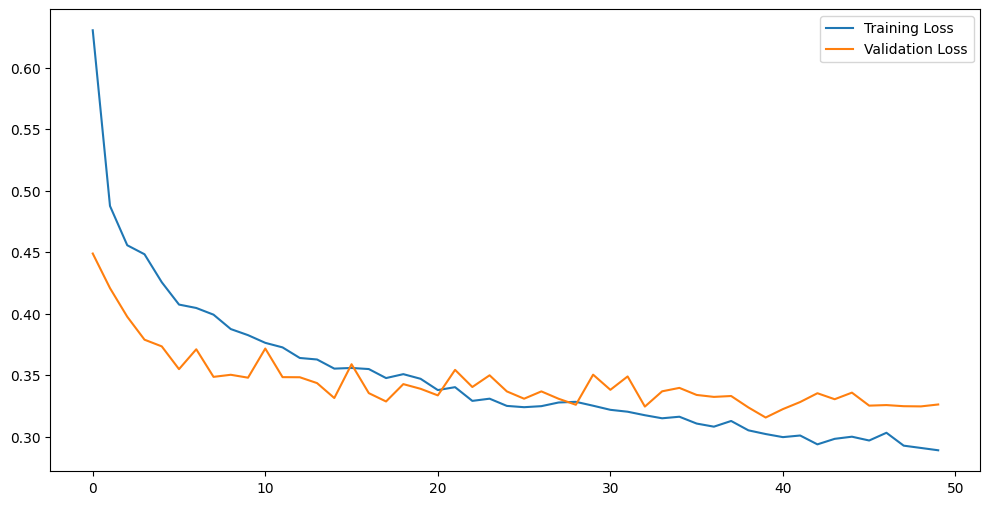

In [36]:
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.legend()
plt.show()

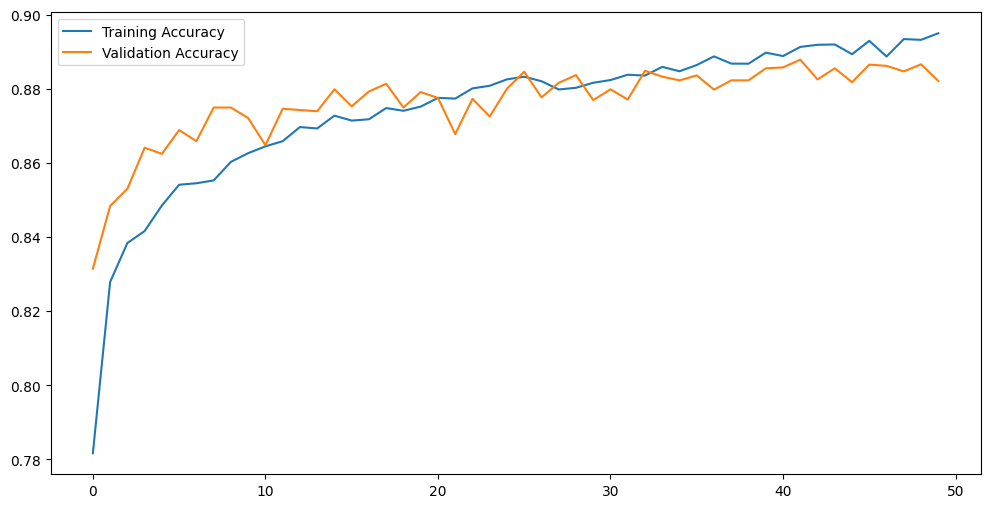

In [37]:
plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.legend()
plt.show()

In [38]:
def search_space_FNN(hp):
  model=Sequential()
  model.add(Flatten(input_shape=(28,28)))
  n_layers=hp.Int('n_layers',min_value=1,max_value=4)
  for i in range(n_layers):
    model.add(Dense(units=hp.Int(f"units_{i}",min_value=16,max_value=256,step=16),
                    activation =hp.Choice(f"activation_{i}",values=['relu','tanh','sigmoid']),
                    kernel_regularizer=l2(hp.Choice(f"regularizer_{i}",values=[0.0,0.001,0.01,0.1])),
              ))
    model.add(BatchNormalization()),
    model.add(Dropout(hp.Float(f"dropout_{i}",min_value=0.1,max_value=0.5,step=0.1)))
  model.add(Dense(10,activation='softmax'))
  optimizer=hp.Choice('optimizer',values=['adam','sgd','rmsprop'])
  model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
  )
  return model

In [39]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.5 MB/s eta 0:00:00


In [40]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [41]:
import os
os.listdir('/content/drive/MyDrive/AI-DEEP learning/fashion mnist')

['best_model.h5',
 'history.pkl',
 'loss.png',
 'accuracy.png',
 'Fashion_mnist',
 ' Fashion_MNIST_FCNN.ipynb']

In [42]:
import keras_tuner as kt


In [43]:
tuner = kt.BayesianOptimization(
    hypermodel=search_space_FNN,
    objective='val_accuracy',
    max_trials=10,
    num_initial_points=2,
    directory='/content/drive/MyDrive/AI-DEEP learning/fashion mnist',
    project_name='Fashion_mnist',
    overwrite=True
)
tuner.search_space_summary()


Search space summary
Default search space size: 6
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 256, 'step': 16, 'sampling': 'linear'}
activation_0 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh', 'sigmoid'], 'ordered': False}
regularizer_0 (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.001, 0.01, 0.1], 'ordered': True}
dropout_0 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'sgd', 'rmsprop'], 'ordered': False}


In [44]:
earlystopping= EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [45]:
#model_checkpoint= ModelCheckpoint(monitor='val_loss',save_best_only=True,filepath='/content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5')

In [46]:
tuner.search(train_images,
             train_labels,
             batch_size=32,
             epochs=10,
             callbacks=[earlystopping],
             validation_split=0.2)

Trial 10 Complete [00h 00m 58s]
val_accuracy: 0.8674166798591614

Best val_accuracy So Far: 0.8692499995231628
Total elapsed time: 00h 11m 29s


In [47]:
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]

"During hyperparameter tuning, the tuner evaluates multiple trials and ranks them based on the objective metric, such as validation accuracy. get_best_hyperparameters(num_trials=1) returns a list containing the highest-ranked trial. Since the result is a list, I use [0] to retrieve the single best set of hyperparameters, which I then use to build and train the final model."

In [48]:
type(best_hps)

keras_tuner.src.engine.hyperparameters.hyperparameters.HyperParameters

In [49]:
dir(best_hps)

['Boolean',
 'Choice',
 'Fixed',
 'Float',
 'Int',
 '__class__',
 '__contains__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_api_export_path',
 '_api_export_symbol_id',
 '_conditions',
 '_conditions_are_active',
 '_exists',
 '_get_name',
 '_hps',
 '_maybe_conditional_scope',
 '_name_scopes',
 '_register',
 '_retrieve',
 '_space',
 '_validate_name',
 'active_scopes',
 'conditional_scope',
 'copy',
 'ensure_active_values',
 'from_config',
 'from_proto',
 'get',
 'get_config',
 'inactive_scopes',
 'is_active',
 'merge',
 'name_scope',
 'space',
 'to_proto',
 'values']

In [50]:
best_hps.values

{'n_layers': 2,
 'units_0': 128,
 'activation_0': 'relu',
 'regularizer_0': 0.001,
 'dropout_0': 0.2,
 'optimizer': 'sgd',
 'units_1': 128,
 'activation_1': 'relu',
 'regularizer_1': 0.1,
 'dropout_1': 0.1,
 'units_2': 224,
 'activation_2': 'sigmoid',
 'regularizer_2': 0.01,
 'dropout_2': 0.2,
 'units_3': 48,
 'activation_3': 'tanh',
 'regularizer_3': 0.1,
 'dropout_3': 0.4}

# Understanding `best_hps` in Keras Tuner

After Bayesian Optimization completes all the trials, we retrieve the best hyperparameters using:

```python
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
```

This returns the **HyperParameters object** corresponding to the **best-performing trial** based on the specified objective (e.g., `val_accuracy`).

---

## Best Hyperparameters

For example, suppose `best_hps.values` returns:

```python
{
    'n_layers': 1,
    'units_0': 256,
    'activation_0': 'sigmoid',
    'regularizer_0': 0.0,
    'dropout_0': 0.5,
    'optimizer': 'adam',

    'units_1': 256,
    'activation_1': 'relu',

    'units_2': 16,
    'activation_2': 'relu',

    'units_3': 16,
    'activation_3': 'sigmoid'
}
```

At first glance, it may appear that the model contains **four hidden layers**, but this is **not true**.

---

## Which Hyperparameters Are Actually Used?

The important hyperparameter is:

```python
'n_layers': 1
```

Our model is built using:

```python
for i in range(n_layers):
    ...
```

Since:

```python
n_layers = 1
```

the loop becomes:

```python
for i in range(1):
```

which means:

```python
i = 0
```

Therefore, **only the first set of hyperparameters is used**.

### Active Hyperparameters

```python
{
    'n_layers': 1,
    'units_0': 256,
    'activation_0': 'sigmoid',
    'regularizer_0': 0.0,
    'dropout_0': 0.5,
    'optimizer': 'adam'
}
```

---

## Best Architecture Found by Bayesian Optimization

```text
Input (28 × 28)
        │
        ▼
Flatten
        │
        ▼
Dense(256, activation='sigmoid')
        │
        ▼
BatchNormalization
        │
        ▼
Dropout(0.5)
        │
        ▼
Dense(10, activation='softmax')
```

This means the tuner is saying:

> **"Among all the architectures I evaluated, this model achieved the best validation accuracy."**

---

## Then Why Do `units_1`, `units_2`, `units_3` Exist?

For example:

```python
'units_1': 256
'activation_1': 'relu'

'units_2': 16
'activation_2': 'relu'

'units_3': 16
'activation_3': 'sigmoid'
```

These hyperparameters are **stored by Keras Tuner because they belong to the search space**, but they are **inactive** for this particular trial.

Since:

```python
n_layers = 1
```

the loop never reaches:

```python
i = 1
i = 2
i = 3
```

Therefore, these hyperparameters are **ignored** when building the final model.

---

## Why Does Keras Tuner Store Them?

Keras Tuner keeps values for **all hyperparameters defined in the search space**, even if some are inactive for the best trial.

This allows it to:

- Maintain a consistent search space across all trials.
- Compare different architectures easily.
- Rebuild models correctly for any value of `n_layers`.

---

## Key Takeaways

- `best_hps` contains the **best trial** found during hyperparameter tuning.
- `best_hps.values` stores values for **all hyperparameters in the search space**.
- Only the hyperparameters corresponding to the selected `n_layers` are actually used to build the model.
- In this example, `n_layers = 1`, so only the hyperparameters for **Layer 0** are active.
- The remaining layer hyperparameters are stored but ignored during model construction.

---

## Interview Perspective

**Question:** Why does `best_hps.values` contain hyperparameters for layers that are not part of the final model?

**Answer:**

Keras Tuner stores values for every hyperparameter defined in the search space. However, only the hyperparameters that satisfy the model-building conditions are active. Since the best trial selected `n_layers = 1`, only the first hidden layer (`units_0`, `activation_0`, `regularizer_0`, and `dropout_0`) is used to construct the final model. The remaining layer-specific hyperparameters are stored for consistency but are ignored because those layers are not created.

In [51]:
best_hps.get('n_layers')

2

In [52]:
for i in range(best_hps.get('n_layers')):
  print(f"layer_{i+1} units: {best_hps.get(f'units_{i}')}")
  print(f"layer_{i+1} activation: {best_hps.get(f'activation_{i}')}")
  print(f"layer_{i+1} regularize: {best_hps.get(f'regularizer_{i}')}")
  print(f"layer_{i+1} dropuout: {best_hps.get(f'dropout_{i}')}")
  print(f"layer_{i+1} optimizer: {best_hps.get(f'optimizer')}")



layer_1 units: 128
layer_1 activation: relu
layer_1 regularize: 0.001
layer_1 dropuout: 0.2
layer_1 optimizer: sgd
layer_2 units: 128
layer_2 activation: relu
layer_2 regularize: 0.1
layer_2 dropuout: 0.1
layer_2 optimizer: sgd


defined a search space where the tuner could choose between 1 and 4 hidden layers, different numbers of neurons, activation functions, dropout rates, L2 regularization values, and optimizers. After evaluating multiple trials, the best-performing model on the validation set had one hidden layer with 256 neurons, sigmoid activation, no L2 regularization, 0.5 dropout, and the Adam optimizer. This indicates that, for my search space and the Fashion MNIST dataset, a simpler architecture generalized better than deeper networks."

In [53]:
best_model=tuner.hypermodel.build(best_hps)

In [54]:
early_stopping=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [55]:
model_checkpoint=ModelCheckpoint(monitor='val_loss',
save_best_only=True,
filepath='/content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5',
mode="min",
verbose=1)

In [56]:
history=best_model.fit(train_images,
               train_labels,
               epochs=10,
               batch_size=32,
               callbacks=[early_stopping,model_checkpoint],
               validation_split=0.2,
               )



Epoch 1/10
1488/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7217 - loss: 6.0872
Epoch 1: val_loss improved from None to 0.81537, saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7787 - loss: 3.0011 - val_accuracy: 0.8193 - val_loss: 0.8154
Epoch 2/10
1480/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8215 - loss: 0.8052
Epoch 2: val_loss improved from 0.81537 to 0.71477, saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8238 - loss: 0.7899 - val_accuracy: 0.8432 - val_loss: 0.7148
Epoch 3/10
1496/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8352 - loss: 0.7384
Epoch 3: val_loss improved from 0.71477 to 0.68854, saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8359 - loss: 0.7354 - val_accuracy: 0.8487 - val_loss: 0.6885
Epoch 4/10
1483/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8435 - loss: 0.7002
Epoch 4: val_loss improved from 0.68854 to 0.66884, saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8415 - loss: 0.7026 - val_accuracy: 0.8463 - val_loss: 0.6688
Epoch 5/10
1491/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8464 - loss: 0.6757
Epoch 5: val_loss improved from 0.66884 to 0.62392, saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8483 - loss: 0.6707 - val_accuracy: 0.8643 - val_loss: 0.6239
Epoch 6/10
1482/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8525 - loss: 0.6541
Epoch 6: val_loss did not improve from 0.62392
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8525 - loss: 0.6504 - val_accuracy: 0.8337 - val_loss: 0.6693
Epoch 7/10
1496/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8508 - loss: 0.6366
Epoch 7: val_loss improved from 0.62392 to 0.61193, saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5



Epoch 7: finished saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8527 - loss: 0.6330 - val_accuracy: 0.8558 - val_loss: 0.6119
Epoch 8/10
1494/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8559 - loss: 0.6177
Epoch 8: val_loss improved from 0.61193 to 0.59943, saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5



Epoch 8: finished saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8564 - loss: 0.6160 - val_accuracy: 0.8638 - val_loss: 0.5994
Epoch 9/10
1491/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8574 - loss: 0.6047
Epoch 9: val_loss did not improve from 0.59943
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8580 - loss: 0.6011 - val_accuracy: 0.8547 - val_loss: 0.6166
Epoch 10/10
1485/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8618 - loss: 0.5895
Epoch 10: val_loss improved from 0.59943 to 0.58644, saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5



Epoch 10: finished saving model to /content/drive/MyDrive/AI-DEEP learning/fashion mnist/best_model.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8614 - loss: 0.5866 - val_accuracy: 0.8585 - val_loss: 0.5864


In [57]:
with open('/content/drive/MyDrive/AI-DEEP learning/fashion mnist/history.pkl', 'wb') as file:
  pkl.dump(history.history,file)

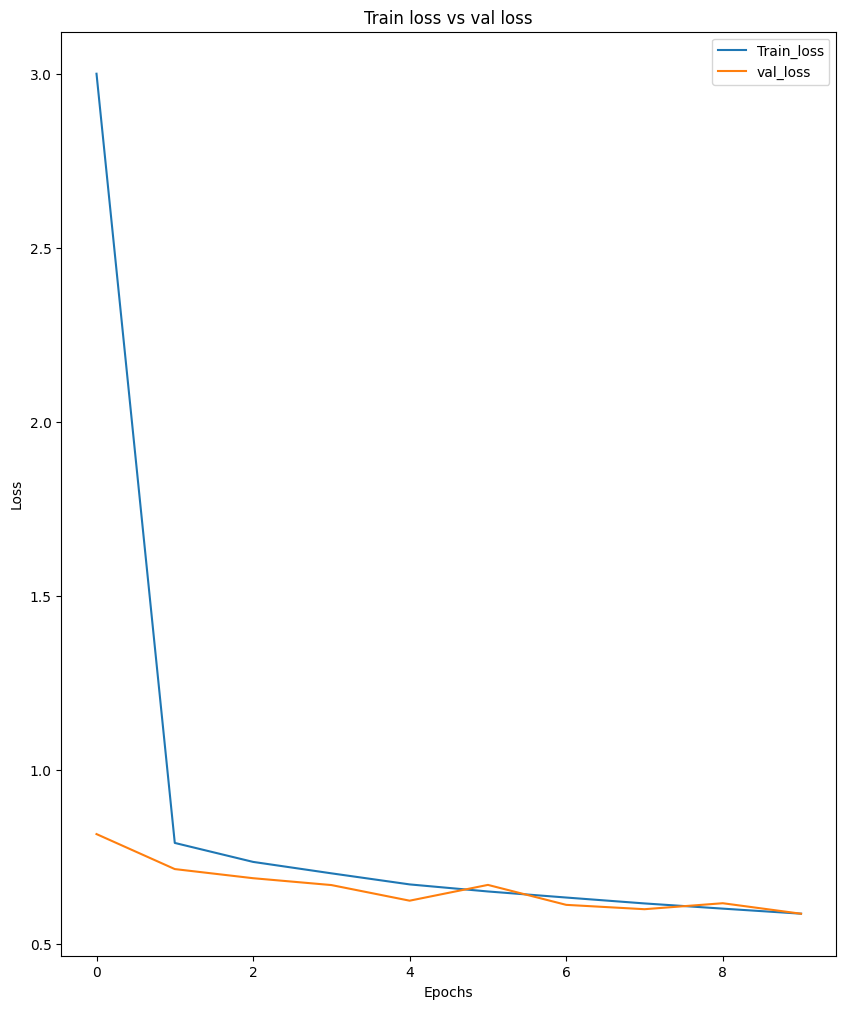

In [58]:
plt.figure(figsize=(10,12))
plt.plot(history.history['loss'], label='Train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Train loss vs val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('/content/drive/MyDrive/AI-DEEP learning/fashion mnist/loss.png')
plt.show()



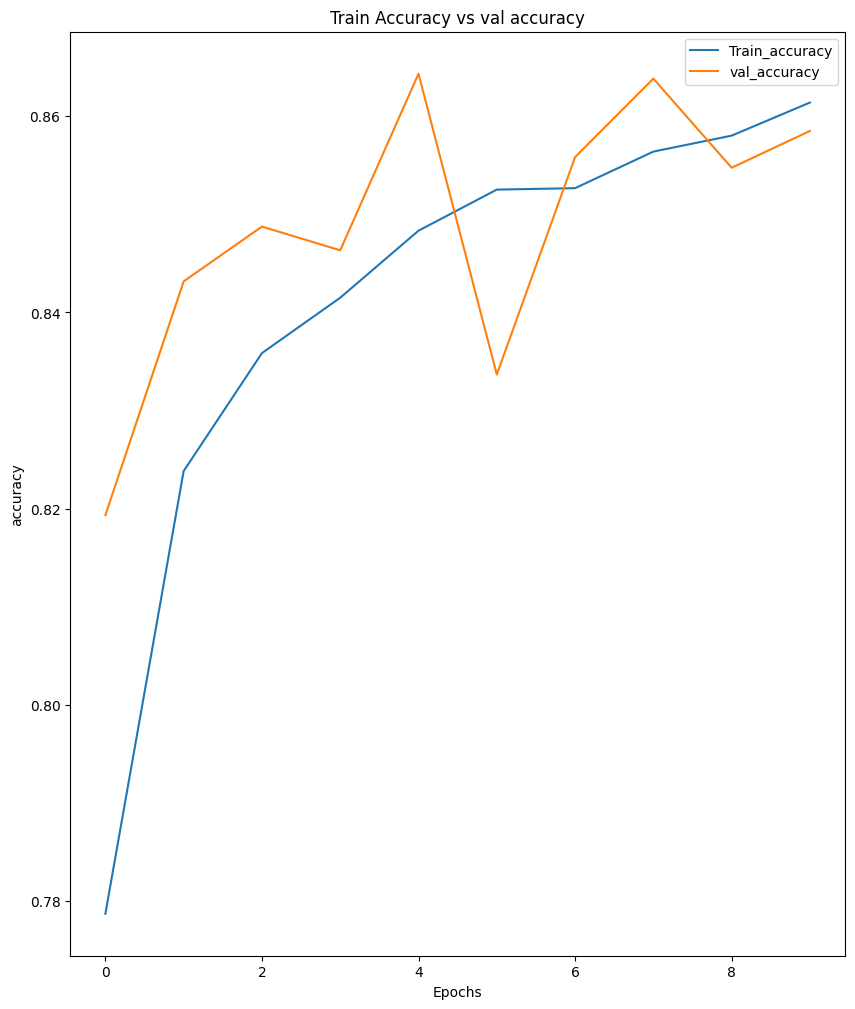

In [59]:
plt.figure(figsize=(10,12))
plt.plot(history.history['accuracy'], label='Train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Train Accuracy vs val accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.savefig('/content/drive/MyDrive/AI-DEEP learning/fashion mnist/accuracy.png')
plt.show()




In [60]:
test_loss,test_accuracy =best_model.evaluate(test_images,test_labels)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8521 - loss: 0.6145
Test Loss: 0.6144715547561646
Test Accuracy: 0.8521000146865845


In [61]:
predictions = best_model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [62]:
(predictions[0])

array([2.8253276e-05, 1.4117818e-03, 4.1677897e-05, 8.1864033e-05,
       6.8813541e-05, 3.0872680e-03, 4.7430538e-05, 6.4097583e-02,
       1.0039561e-03, 9.3013132e-01], dtype=float32)

In [63]:
predictions.shape

(10000, 10)

In [64]:
test_labels.shape

(10000, 10)

NumPy looks at each row (each prediction) and returns the index of the maximum probability.

In [65]:
predicted_labels = np.argmax(predictions, axis=1)

In [66]:
predicted_labels .shape

(10000,)

In [79]:
predicted_labels[:10]

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [67]:
type(predicted_labels)

numpy.ndarray

In [68]:
true_labels = np.argmax(test_labels, axis=1)

In [69]:
true_labels.shape

(10000,)

In [80]:
true_labels[:10]

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [70]:
type(true_labels)

numpy.ndarray

In [71]:
accuracy_score(true_labels,predicted_labels)

0.8521

In [72]:
print(classification_report(true_labels, predicted_labels))

              precision    recall  f1-score   support

           0       0.75      0.87      0.81      1000
           1       0.99      0.96      0.97      1000
           2       0.73      0.74      0.74      1000
           3       0.81      0.93      0.87      1000
           4       0.73      0.81      0.76      1000
           5       0.99      0.91      0.95      1000
           6       0.79      0.42      0.55      1000
           7       0.89      0.97      0.93      1000
           8       0.91      0.97      0.94      1000
           9       0.95      0.94      0.94      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [75]:
confusion_matrix(true_labels,predicted_labels)

array([[871,   0,  31,  46,   2,   0,  34,   0,  15,   1],
       [  3, 956,   2,  29,   5,   0,   3,   0,   2,   0],
       [ 21,   1, 745,  14, 171,   1,  27,   0,  20,   0],
       [ 26,   5,  19, 926,  11,   0,   8,   0,   5,   0],
       [  1,   1,  74,  65, 806,   0,  38,   0,  15,   0],
       [  0,   0,   0,   2,   0, 912,   0,  50,   5,  31],
       [239,   0, 138,  52, 115,   0, 423,   0,  33,   0],
       [  0,   0,   0,   0,   0,   8,   0, 971,   0,  21],
       [  2,   1,   5,   4,   1,   1,   2,   9, 975,   0],
       [  0,   0,   0,   0,   0,   2,   0,  61,   1, 936]])

In [77]:
import numpy as np

wrong_indices = np.where(predicted_labels != true_labels)[0]

print("Number of Wrong Predictions:", len(wrong_indices))

Number of Wrong Predictions: 1479


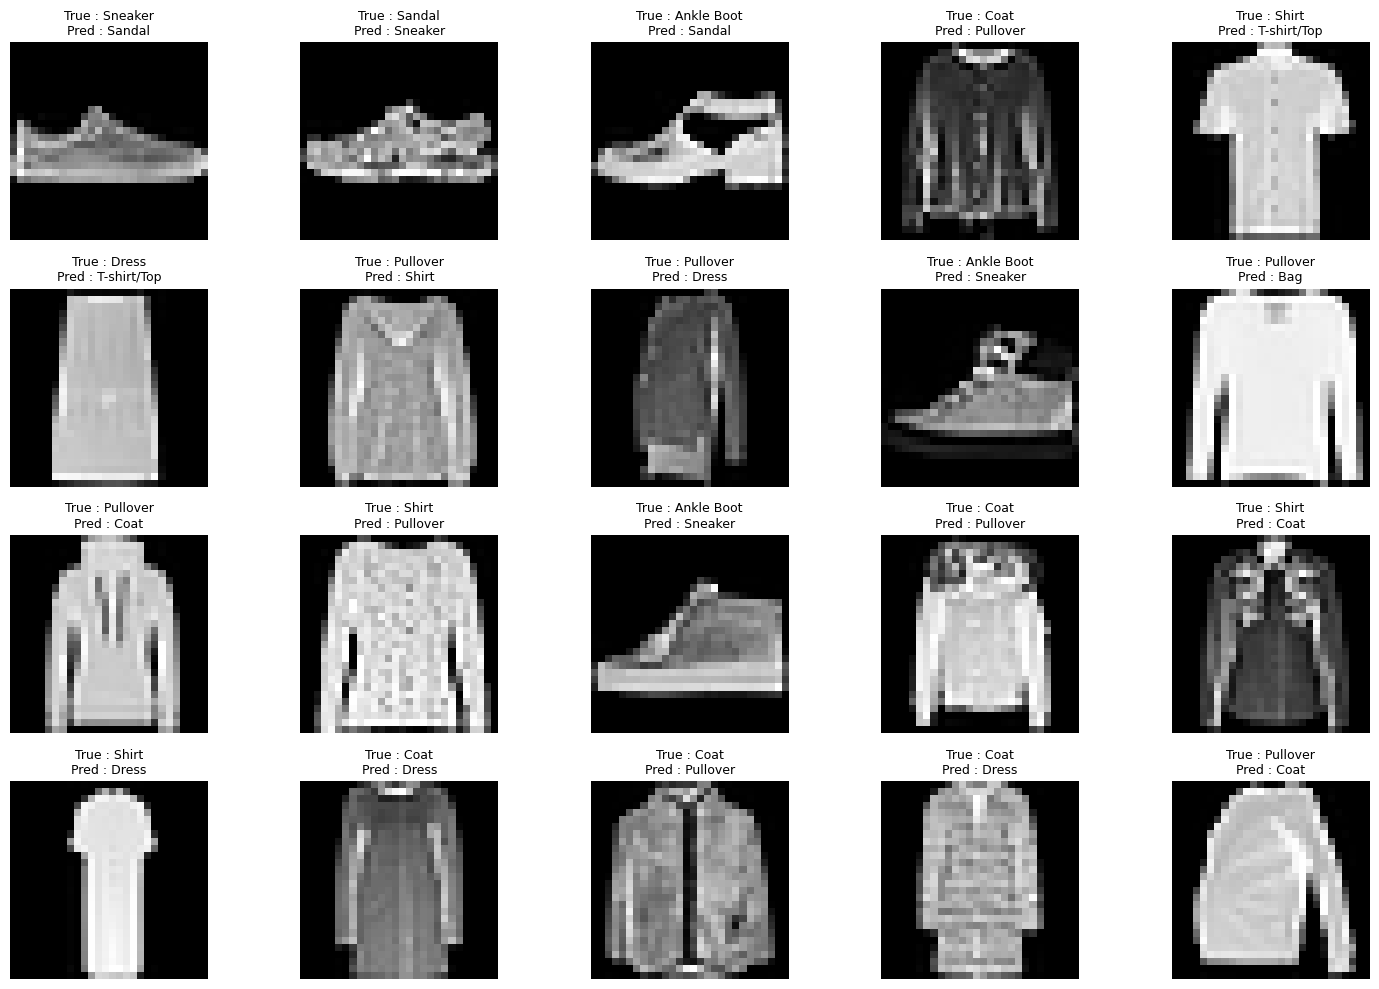

In [78]:
import matplotlib.pyplot as plt

class_names = [
    'T-shirt/Top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

plt.figure(figsize=(15,10))

for i, idx in enumerate(wrong_indices[:20]):   # First 20 wrong predictions

    plt.subplot(4,5,i+1)
    plt.imshow(test_images[idx], cmap='gray')

    plt.title(
        f"True : {class_names[true_labels[idx]]}\n"
        f"Pred : {class_names[predicted_labels[idx]]}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()